# Analise do FOMC - Federal Open Market Committee

Este notebook reproduz a analise das reunioes do FOMC.

**Fonte dos Dados:**
- Bloomberg Terminal (UST 2Y, 10Y, SPX, DXY)
- Federal Reserve: https://www.federalreserve.gov/monetarypolicy/fomccalendars.htm
- PDFs de projecoes (Summary of Economic Projections)

In [1]:
# Configuracao do ambiente
import sys
from pathlib import Path

# Adiciona o diretorio raiz ao path (4 niveis: notebooks -> fomc -> reports -> src -> root)
project_root = Path.cwd().parents[3]
if str(project_root / 'src') not in sys.path:
    sys.path.insert(0, str(project_root / 'src'))

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# Configuracao de estilo
from classes.config import COPOM, FIGSIZE, DPI, plot_config, clean_axes

plot_config(6)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# ============================================
# CONFIGURACAO: Data da reuniao FOMC
# ============================================
# Formato: YYYYMMDD
MEETING_DATE = '20251210'  # Reuniao mais recente
# ============================================

In [2]:
# Importa os modulos do FOMC
from reports.fomc.core.data_loader import (
    get_fomc_dates,
    get_meeting_documents,
    load_sep_data,
    fetch_market_reaction,
)
from reports.fomc.core.pdf_parser import (
    parse_projection_table,
    parse_statement,
    get_projection_dates,
)
from reports.fomc.core.calculations import (
    process_dot_plot,
    format_projection_table,
    calculate_rate_path,
    get_meeting_summary,
)
from reports.fomc.core.word_export import (
    WORD_DPI,
    WORD_FIGSIZE,
    WORD_FIGSIZE_DASHBOARD,
    create_dot_plot_chart,
    create_sep_charts,
    create_market_reaction_charts,
    create_summary_table_image,
    create_rate_path_chart,
    save_chart_for_word,
)

## 1. Reunioes Disponiveis

Lista de reunioes do FOMC com documentos disponiveis.

In [3]:
# Lista reunioes disponiveis
fomc_dates = get_fomc_dates()
projection_dates = get_projection_dates()

print(f"Reunioes disponiveis: {len(fomc_dates)}")
print(f"Reunioes com projecoes (SEP): {len(projection_dates)}")
print(f"\nUltimas 10 reunioes:")
for date in fomc_dates[:10]:
    has_sep = "[SEP]" if date in projection_dates else ""
    print(f"  {date} {has_sep}")

Reunioes disponiveis: 50
Reunioes com projecoes (SEP): 23

Ultimas 10 reunioes:
  20251210 [SEP]
  20251029 
  20250917 [SEP]
  20250730 
  20250618 [SEP]
  20250507 
  20250319 [SEP]
  20250129 
  20241218 [SEP]
  20241107 


In [4]:
# Busca documentos da reuniao selecionada
documents = get_meeting_documents(MEETING_DATE)

print(f"Documentos para reuniao {MEETING_DATE}:")
for doc_type, path in documents.items():
    status = "Disponivel" if path else "Nao encontrado"
    print(f"  {doc_type}: {status}")

Documentos para reuniao 20251210:
  statement: Disponivel
  minutes: Disponivel
  presser: Disponivel
  projections: Disponivel


## 2. Decisao do FOMC (Statement)

Analise do comunicado oficial da reuniao.

In [5]:
# Parse do statement
statement_data = {}
if documents['statement']:
    statement_data = parse_statement(documents['statement'])
    
    print("=" * 50)
    print("DECISAO DO FOMC")
    print("=" * 50)
    print(f"Decisao: {statement_data.get('decision', 'N/A').upper()}")
    print(f"Taxa alvo: {statement_data.get('target_rate_low', 'N/A')}% - {statement_data.get('target_rate_high', 'N/A')}%")
    print(f"Unanime: {'Sim' if statement_data.get('unanimous') else 'Nao'}")
    if statement_data.get('dissenters'):
        print(f"Dissidentes: {', '.join(statement_data['dissenters'])}")
    print("=" * 50)
else:
    print("Statement nao disponivel para esta reuniao.")

DECISAO DO FOMC
Decisao: CUT
Taxa alvo: 3.5% - 3.75%
Unanime: Sim


## 3. Projecoes Economicas (SEP)

Summary of Economic Projections - Dot Plot e projecoes de GDP, desemprego e inflacao.

In [6]:
# Parse das projecoes
projection_data = {}
if documents['projections']:
    projection_data = parse_projection_table(documents['projections'])
    
    print("Projecoes Medians:")
    display(projection_data.get('medians', pd.DataFrame()))
else:
    print("Projecoes nao disponiveis para esta reuniao.")
    print("(SEP so e divulgado em reunioes trimestrais: Mar, Jun, Set, Dez)")

Projecoes Medians:


,Variable,2025,2026,2027,2028
0,Change in real GDP,1.7,2.3,2.0,1.9
1,Unemployment rate,4.5,4.4,4.2,4.2
2,PCE inflation,2.9,2.4,2.1,2.0
3,Core PCE inflation,3.0,2.5,2.1,NaN
4,Federal funds rate,3.6,3.4,3.1,3.1


In [7]:
# Gera tabela formatada de projecoes
if projection_data and 'medians' in projection_data:
    formatted_table = format_projection_table(projection_data['medians'])
    
    # Salva tabela estilizada (convencao CLAUDE.md: output/ na raiz do projeto)
    output_dir = project_root / 'output' / 'reports' / 'fomc'
    output_dir.mkdir(parents=True, exist_ok=True)
    create_summary_table_image(
        data=formatted_table,
        output_path=output_dir / 'projections_table_word.png',
        title='SEP',
    )
    print(f"Tabela salva em: {output_dir / 'projections_table_word.png'}")
    
    display(formatted_table)

Tabela salva em: e:\Github\marc3lom\py-bcb\output\reports\fomc\projections_table_word.png


,Indicador,2025,2026,2027,2028
0,Variacao do PIB Real,1.7,2.3,2.0,1.9
1,Taxa de Desemprego,4.5,4.4,4.2,4.2
2,Inflacao PCE,2.9,2.4,2.1,2.0
3,Inflacao PCE Nucleo,3.0,2.5,2.1,NaN
4,Fed Funds Rate,3.6,3.4,3.1,3.1


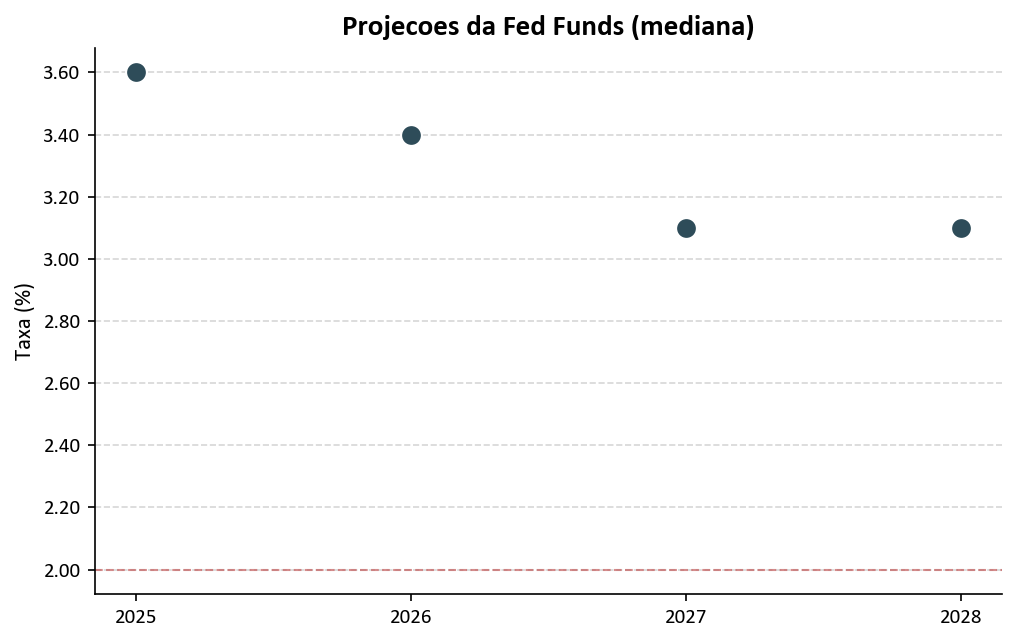

Grafico salvo em: e:\Github\marc3lom\py-bcb\output\reports\fomc\dot_plot_word.png


In [8]:
# Dot Plot - Projecoes da Fed Funds
if projection_data and 'medians' in projection_data:
    dot_data = process_dot_plot(projection_data)
    
    output_dir = project_root / 'output' / 'reports' / 'fomc'
    output_dir.mkdir(parents=True, exist_ok=True)
    fig = create_dot_plot_chart(
        dot_data,
        output_path=output_dir / 'dot_plot_word.png',
        title='Projecoes da Fed Funds (mediana)',
    )
    plt.show()
    print(f"Grafico salvo em: {output_dir / 'dot_plot_word.png'}")

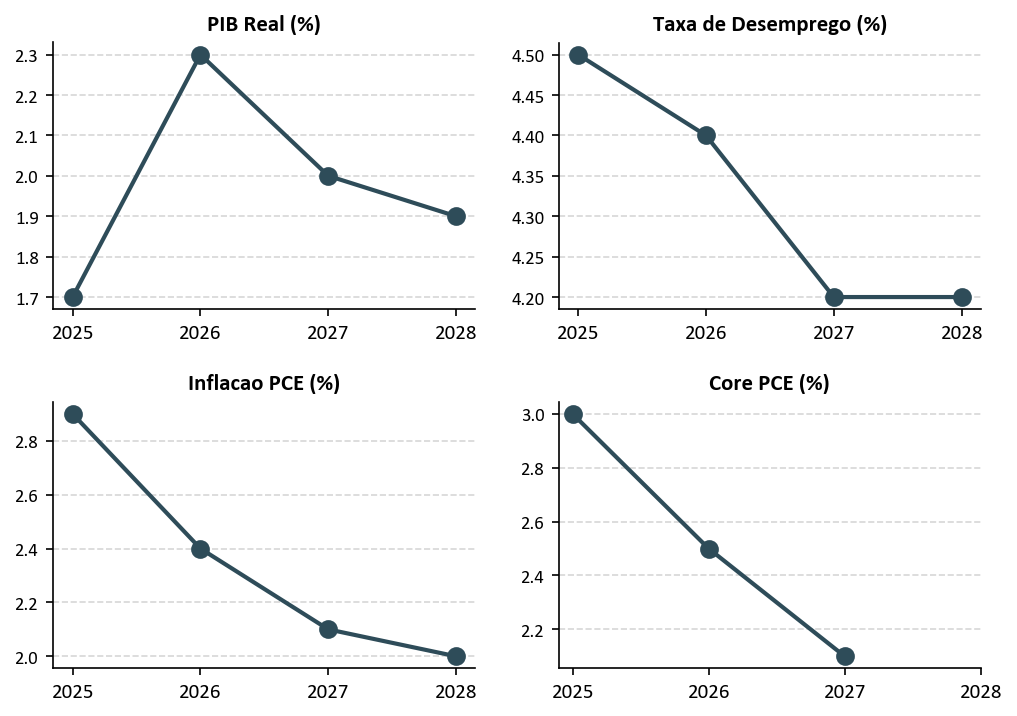

Dashboard salvo em: e:\Github\marc3lom\py-bcb\output\reports\fomc\sep_dashboard_word.png


In [9]:
# Dashboard de Projecoes Economicas (4 paineis)
if projection_data and 'medians' in projection_data:
    output_dir = project_root / 'output' / 'reports' / 'fomc'
    output_dir.mkdir(parents=True, exist_ok=True)
    fig = create_sep_charts(
        projection_data['medians'],
        prior_df=None,  # Adicionar projecoes anteriores se disponivel
        output_path=output_dir / 'sep_dashboard_word.png',
    )
    plt.show()
    print(f"Dashboard salvo em: {output_dir / 'sep_dashboard_word.png'}")

## 4. Trajetoria da Taxa Fed Funds

Caminho esperado da taxa de juros com base nas projecoes.

Trajetoria Esperada da Taxa:


,year,rate,move,move_bps
0,2025,3.6,-0.15,-14
1,2026,3.4,-0.20,-20
2,2027,3.1,-0.30,-29
3,2028,3.1,0.00,0


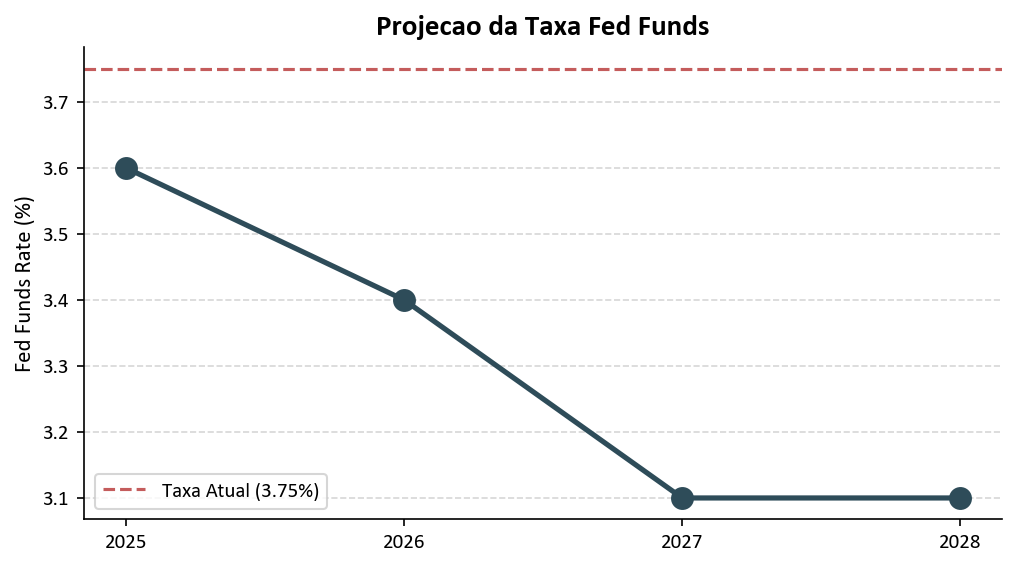

In [10]:
# Calcula trajetoria esperada da taxa
if projection_data and 'medians' in projection_data:
    # Taxa atual (extrair do statement ou usar valor conhecido)
    current_rate = statement_data.get('target_rate_high', 4.5)
    
    rate_path = calculate_rate_path(
        projection_data['medians'],
        current_rate=current_rate,
    )
    
    print("Trajetoria Esperada da Taxa:")
    display(rate_path)
    
    # Grafico
    output_dir = project_root / 'output' / 'reports' / 'fomc'
    output_dir.mkdir(parents=True, exist_ok=True)
    fig = create_rate_path_chart(
        rate_path,
        current_rate=current_rate,
        output_path=output_dir / 'rate_path_word.png',
    )
    plt.show()

## 5. Reacao de Mercado

Movimentacao intraday dos ativos durante o anuncio do FOMC.

In [11]:
# Busca dados de mercado (requer Bloomberg)
try:
    market_data = fetch_market_reaction(
        date=MEETING_DATE,
        start_time='13:00',
        end_time='16:00',
    )
    print(f"Dados de mercado carregados: {len(market_data)} pontos")
    
    # Grafico de reacao de mercado
    output_dir = project_root / 'output' / 'reports' / 'fomc'
    output_dir.mkdir(parents=True, exist_ok=True)
    fig = create_market_reaction_charts(
        market_data,
        statement_time='14:00',
        output_path=output_dir / 'market_reaction_word.png',
    )
    plt.show()
    print(f"Grafico salvo em: {output_dir / 'market_reaction_word.png'}")
    
except RuntimeError as e:
    print(f"Bloomberg nao disponivel: {e}")
    print("Para visualizar a reacao de mercado, execute com o Bloomberg Terminal ativo.")

Bloomberg nao disponivel: Failed to fetch intraday data: unhashable type: 'list'
Para visualizar a reacao de mercado, execute com o Bloomberg Terminal ativo.


## 6. Resumo da Reuniao

Compilacao das principais informacoes da reuniao.

In [12]:
# Gera resumo da reuniao
summary = get_meeting_summary(
    statement_data=statement_data,
    projection_data=projection_data if projection_data else None,
)

print("=" * 50)
print(f"RESUMO DA REUNIAO FOMC - {MEETING_DATE}")
print("=" * 50)
print(f"Decisao: {summary['decisao']}")
print(f"Taxa Alvo: {summary['taxa_alvo']}")
print(f"Votacao: {'Unanime' if summary['unanime'] else 'Com dissidentes'}")

if summary['projecoes_resumo']:
    print("\nProjecoes (mediana):")
    for indicator, values in summary['projecoes_resumo'].items():
        print(f"  {indicator}:")
        for year, val in values.items():
            if val is not None:
                print(f"    {year}: {val}")

print("=" * 50)

RESUMO DA REUNIAO FOMC - 20251210
Decisao: Corte
Taxa Alvo: 3.50% - 3.75%
Votacao: Unanime

Projecoes (mediana):
  PIB:
    2025: 1.7
    2026: 2.3
    2027: 2.0
  Desemprego:
    2025: 4.5
    2026: 4.4
    2027: 4.2
  PCE:
    2025: 2.9
    2026: 2.4
    2027: 2.1
  Core PCE:
    2025: 3.0
    2026: 2.5
    2027: 2.1
  Fed Funds:
    2025: 3.6
    2026: 3.4
    2027: 3.1


## 7. Exportar Dados

Exporta os dados processados para arquivo Excel.

In [13]:
# Exporta dados para Excel
output_dir = project_root / 'output' / 'reports' / 'fomc'
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / f'fomc_analysis_{MEETING_DATE}.xlsx'

with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    # Sheet 1: Projecoes
    if projection_data and 'medians' in projection_data:
        projection_data['medians'].to_excel(writer, sheet_name='Projecoes', index=False)
    
    # Sheet 2: Trajetoria da taxa
    if 'rate_path' in dir() and not rate_path.empty:
        rate_path.to_excel(writer, sheet_name='Trajetoria Taxa', index=False)
    
    # Sheet 3: Resumo
    resumo_df = pd.DataFrame([{
        'Data': MEETING_DATE,
        'Decisao': summary.get('decisao', ''),
        'Taxa Alvo': summary.get('taxa_alvo', ''),
        'Unanime': 'Sim' if summary.get('unanime') else 'Nao',
    }])
    resumo_df.to_excel(writer, sheet_name='Resumo', index=False)

print(f"Dados exportados para: {output_path}")

Dados exportados para: e:\Github\marc3lom\py-bcb\output\reports\fomc\fomc_analysis_20251210.xlsx


---

**Notas:**
- Este notebook pode ser re-executado a cada reuniao do FOMC
- Projecoes (SEP) sao divulgadas apenas em reunioes trimestrais (Mar, Jun, Set, Dez)
- Dados de mercado requerem Bloomberg Terminal ativo
- Graficos sao salvos automaticamente na pasta `output/`